# Analyse préliminaire 

Avant de faire le moindre entraînement, nécessité de regarder le rapport entre notre corpus et les baseline. Nécessité de construire un benchmark quali/quanti des modèles pour 1) orienter ce qui peut-être/doit être fait 2) évaluer les performances de l'entraînement.

Notamment, vérifier les choses suivantes :
- est-ce que les interventions d'un même débat présente une proximité sémantique forte *par rapport aux* interventions de débats différents ?
- est-ce que les interventions d'un même débat montrent une proximité sémantique équivalente selon s'il y a accord ou désaccord ?

In [39]:
import pandas as pd
import seaborn as sns
import numpy as np
from ast import literal_eval
from sklearn.metrics.pairwise import cosine_distances, paired_cosine_distances
import matplotlib.pyplot as plt
from os.path import join
from transformers import AutoTokenizer

## Analyse descriptive de corpus

In [18]:
dataset = pd.read_csv("./assets/dataset.csv")

In [19]:
# Check for missing values
print("Missing values in each column:")

for column in dataset.columns:
    missing_count = dataset[column].isnull().sum()
    print(f"{column}: {missing_count} missing values")

Missing values in each column:
speech_id: 0 missing values
debate_id: 0 missing values
speech_date: 0 missing values
speech_subject_1: 0 missing values
speech_subject_2: 20 missing values
speech_subject_3: 0 missing values
speaker_name: 0 missing values
speaker_group: 4473 missing values
speaker_government: 0 missing values
vote: 0 missing values
source: 0 missing values
speech: 0 missing values
amendments: 2777 missing values
amendments_precised: 19180 missing values


In [20]:
# Is missing speaker_group because in government ?
print("Seaker_group vs government")
has_no_group = dataset["speaker_group"].isnull()
cm = pd.crosstab(
    has_no_group,
    dataset["speaker_government"],
    rownames=["has_no_group"],
    colnames=["speaker_government"],
    dropna=False
)
print(cm)

Seaker_group vs government
speaker_government  False  True 
has_no_group                    
False               21699      0
True                    3   4470


In [21]:
missing_group = dataset[dataset["speaker_group"].isnull() & ~dataset["speaker_government"]]
missing_group

,speech_id,debate_id,speech_date,speech_subject_1,speech_subject_2,speech_subject_3,speaker_name,speaker_group,speaker_government,vote,source,speech,amendments,amendments_precised
12414,VTANR5L16V107-16-219949,VTANR5L16V107,2022-07-23,Projet de loi de finances rectificative pour 2022,Discussion des articles (suite),Après l’article 1 er,Mme Sophie Taillé-Polian,NaN,False,CONTRE,amendment,Mme Sophie Taillé-Polian. Des rapports qui dém...,746|3|904|958|261,NaN
20678,VTANR5L17V5104-17-156844,VTANR5L17V5104,2026-01-22,Inscrire la mouvance des Frères musulmans sur ...,Discussion des articles (suite),Article unique,Plusieurs députés du groupe LFI-NFP,NaN,False,CONTRE,amendment,Si !,7,NaN
25542,VTANR5L17V1721-17-328643,VTANR5L17V1721,2025-05-15,Lutte contre la mortalité infantile,Discussion des articles (suite),Article 3,Yannick Neuder,NaN,False,CONTRE,amendment,Même avis.,37,NaN


In [22]:
# Count unique values for each column
print("unique values in the dataset")
for column in dataset.columns:
    unique_count = dataset[column].nunique()
    print(f"{column}: {unique_count} unique values")

unique values in the dataset
speech_id: 26172 unique values
debate_id: 5308 unique values
speech_date: 552 unique values
speech_subject_1: 317 unique values
speech_subject_2: 83 unique values
speech_subject_3: 526 unique values
speaker_name: 1023 unique values
speaker_group: 15 unique values
speaker_government: 2 unique values
vote: 2 unique values
source: 4 unique values
speech: 24011 unique values
amendments: 3419 unique values
amendments_precised: 3165 unique values


In [27]:
qwen_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-Embedding-0.6B")
camembert_tokenizer = AutoTokenizer.from_pretrained("Lajavaness/sentence-camembert-large")

def qwen_length(string):
    tokens = qwen_tokenizer(string)
    return len(tokens["input_ids"])

def camembert_length(string):
    tokens = camembert_tokenizer(string)
    return len(tokens["input_ids"])

# Calculate speech length as number of words for each speech
dataset['speech_tokens_qwen'] = dataset['speech'].apply(qwen_length)
dataset['speech_tokens_camembert'] = dataset['speech'].apply(camembert_length)

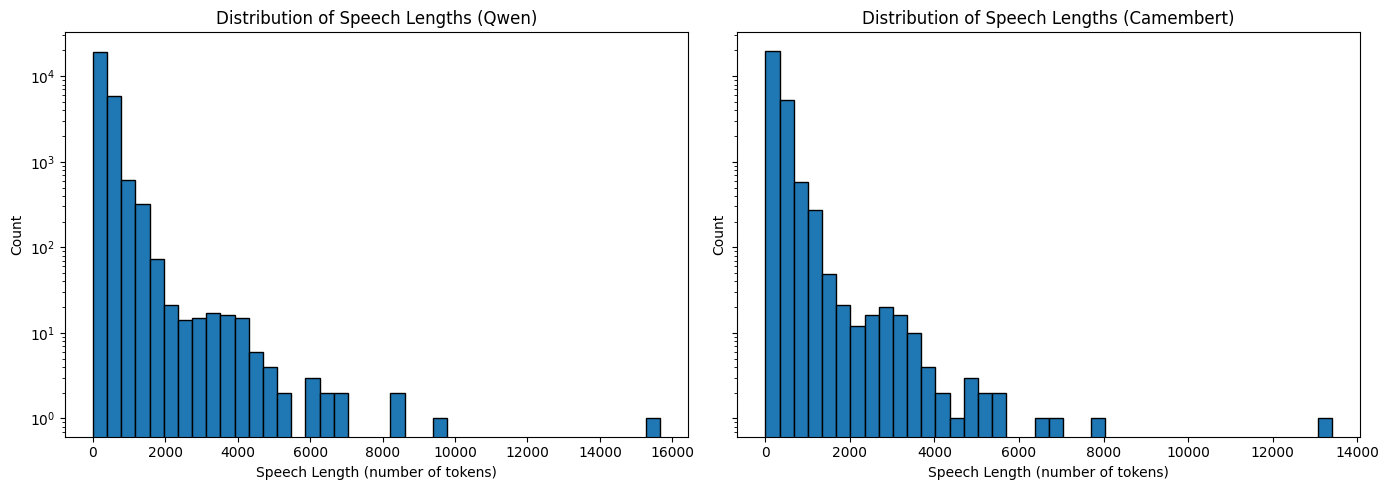

In [29]:
# Plot the distribution of token lengths for both tokenizers
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].hist(dataset['speech_tokens_qwen'], bins=40, edgecolor='black', log=True)
axes[0].set_title('Distribution of Speech Lengths (Qwen)')
axes[0].set_xlabel('Speech Length (number of tokens)')
axes[0].set_ylabel('Count')

axes[1].hist(dataset['speech_tokens_camembert'], bins=40, edgecolor='black', log=True)
axes[1].set_title('Distribution of Speech Lengths (Camembert)')
axes[1].set_xlabel('Speech Length (number of tokens)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


In [31]:
# more precisely, check for very short speeches (e.g., less than 10 words)
short_speeches = dataset[dataset['speech_tokens_qwen'] < 10]
print(f"Number of speeches with less than 10 words: {len(short_speeches)}")
short_speeches.head(20)

Number of speeches with less than 10 words: 2143


,speech_id,debate_id,speech_date,speech_subject_1,speech_subject_2,speech_subject_3,speaker_name,speaker_group,speaker_government,vote,source,speech,amendments,amendments_precised,speech_tokens_qwen,speech_tokens_camembert
8,VTANR5L15V753-15-336,VTANR5L15V753,2018-06-02,"Évolution du logement, de l’aménagement et du ...",Discussion des articles (suite),Article 25,Jacques Mézard,NaN,True,CONTRE,amendment,Même avis.,2061,NaN,5,5
23,VTANR5L15V1732-15-1479,VTANR5L15V1732,2019-03-14,Croissance et transformation des entreprises,Discussion des articles (suite),Article 49,Marie-Noëlle Battistel,SOC,False,POUR,amendment,Il est défendu.,13,13,7,6
26,VTANR5L15V1733-15-1533,VTANR5L15V1733,2019-03-14,Croissance et transformation des entreprises,Discussion des articles (suite),Article 49,Bruno Le Maire,NaN,True,CONTRE,amendment,Même avis.,822,NaN,5,5
35,VTANR5L15V807-15-1858,VTANR5L15V807,2018-06-04,"Évolution du logement, de l’aménagement et du ...",Discussion des articles (suite),Article 35,Thibault Bazin,LR,False,POUR,amendment,Défendu !,1464|205|2858|2159|378|623|199|984|1133,1133,7,8
37,VTANR5L15V807-15-1862,VTANR5L15V807,2018-06-04,"Évolution du logement, de l’aménagement et du ...",Discussion des articles (suite),Article 35,Bertrand Pancher,UDI,False,POUR,amendment,Défendu !,1464|205|2858|2159|378|623|199|984|1133,2159,7,8
43,VTANR5L15V807-15-1890,VTANR5L15V807,2018-06-04,"Évolution du logement, de l’aménagement et du ...",Discussion des articles (suite),Article 35,Laurianne Rossi,LREM,False,POUR,amendment,Je retire également le mien.,1464|205|2858|2159|378|623|199|984|1133,NaN,8,8
44,VTANR5L15V807-15-1893,VTANR5L15V807,2018-06-04,"Évolution du logement, de l’aménagement et du ...",Discussion des articles (suite),Article 35,Alain Ramadier,LR,False,POUR,amendment,Oui.,1464|205|2858|2159|378|623|199|984|1133,NaN,4,4
45,VTANR5L15V807-15-1896,VTANR5L15V807,2018-06-04,"Évolution du logement, de l’aménagement et du ...",Discussion des articles (suite),Article 35,Jean-Louis Masson,LR,False,POUR,amendment,Je le retire.,1464|205|2858|2159|378|623|199|984|1133,NaN,5,6
50,VTANR5L15V809-15-2057,VTANR5L15V809,2018-06-04,"Évolution du logement, de l’aménagement et du ...",Discussion des articles (suite),Après l’article 35,Jacques Mézard,NaN,True,CONTRE,amendment,Même avis.,2727,NaN,5,5
51,VTANR5L15V809-15-2059,VTANR5L15V809,2018-06-04,"Évolution du logement, de l’aménagement et du ...",Discussion des articles (suite),Après l’article 35,François Pupponi,SOC,False,POUR,amendment,"Non, monsieur le président.",2727,NaN,9,8


In [30]:
# Check if some speaker_name have a change in there affilliation to	speaker_group
speaker_group_changes = dataset.groupby('speaker_name')['speaker_group'].nunique()
speakers_with_changes = speaker_group_changes[speaker_group_changes > 1]
print(f"Number of speakers with changes in speaker_group: {len(speakers_with_changes)}")


# For each speaker with changes, show their different groups and the first/last speech_date for each group
result = (
    dataset[dataset['speaker_name'].isin(speakers_with_changes.index)]
    .groupby(['speaker_name', 'speaker_group'])['speech_date']
    .agg(['min', 'max'])
    .reset_index()
)

# Show only the first 10 speakers with changes for brevity
for speaker in speakers_with_changes.index[:10]:
    print(f"\nSpeaker: {speaker}")
    display(result[result['speaker_name'] == speaker])

Number of speakers with changes in speaker_group: 99

Speaker: Adrien Quatennens


,speaker_name,speaker_group,min,max
0,Adrien Quatennens,LFI,2017-09-25,2022-07-21
1,Adrien Quatennens,NI,2023-02-07,2023-02-16



Speaker: Agnès Firmin Le Bodo


,speaker_name,speaker_group,min,max
2,Agnès Firmin Le Bodo,AGIR-E,2020-06-15,2021-12-01
3,Agnès Firmin Le Bodo,HOR,2024-05-29,2026-02-02
4,Agnès Firmin Le Bodo,UDI,2017-12-07,2020-02-21



Speaker: Agnès Thill


...

,speaker_name,speaker_group,min,max
16,Antoine Herth,AGIR-E,2020-10-06,2020-10-06
17,Antoine Herth,UDI,2018-04-11,2019-06-27



Speaker: Aurélien Pradié


,speaker_name,speaker_group,min,max
18,Aurélien Pradié,LR,2018-07-17,2024-06-05
19,Aurélien Pradié,NI,2025-11-05,2025-11-12



Speaker: Aurélien Taché


,speaker_name,speaker_group,min,max
20,Aurélien Taché,ECOLO,2022-10-17,2023-12-06
21,Aurélien Taché,EDS,2020-07-08,2020-09-16
22,Aurélien Taché,LFI,2025-02-06,2025-06-27
23,Aurélien Taché,LREM,2018-06-15,2018-07-25


## Comparaison de distance accord/désaccord intra/inter débats

On prend deux sources de données :
- notre dataset d'interventions à l'Assemblée lié à un scrutin commun
- le dataset X-Stance des paires question/commentaire généré depuis la plateforme Suisse Smartvote.

Méthode `compute_stats` 

- _Intra-débat_. On regroupe les interventions au sein d'un même débat. On calcule les distances cosinus de toutes les combinaisons d'interventions au sein de ce même débat selon si a) la combinaison est en accord (vote similaire) b) la combinaison est en désaccord (vote différent). On concatène toutes ces distances et on calcule 1) la moyenne 2) l'écart-type. Parce que notre dataset nous le permet, on regarde la différence de distance selon si le débat porte sur des amendements, des articles, des motions de rejet préalable ou des explications de vote.
- _Inter-débat_. On prend un échantillon d'interventions issus de débats différents. On applique la même méthode que pour les interventions intra-débats. On calcule moyenne et écart-type.

Méthode `compute_stats_xstance`

- _Intra-débat_. On regroupe les `comments` d'une même question. On calcule les distances cosinus de tous les comments liés par une même question selon si a) la combinaison est en accord (label similaire) b) la combinaison est en désaccord (label différent). On concatène toutes ces distances et on calcule 1) la moyenne 2) l'écart-type.
- _Intra-débat_. On prend un échantillon de comments issus de questions différentes. On applique la même méthode que pour les interventions intra-débats. On calcule moyenne et écart-type. 

Chaque comparaison est faite avec `Lajavaness/sentence-camembert-large`, `Qwen/Qwen3-Embedding-0.6B` and `vahidthegreat/StanceAware-SBERT`

### Granularité : interventions

In [36]:
def compute_stats(dir = "embed"):
    stats = {
        "inter": {
            "ALL": np.array([]),
            "AGREEMENT": np.array([]),
            "DESAGREEMENT": np.array([]),
        },
        "intra": {
            "amendments": {
                "ALL": np.array([]),
                "AGREEMENT": np.array([]),
                "DESAGREEMENT": np.array([]),
            },
            "articles": {
                "ALL": np.array([]),
                "AGREEMENT": np.array([]),
                "DESAGREEMENT": np.array([]),
            },
            "explanations": {
                "ALL": np.array([]),
                "AGREEMENT": np.array([]),
                "DESAGREEMENT": np.array([]),
            },
            "motions_rejet": {
                "ALL": np.array([]),
                "AGREEMENT": np.array([]),
                "DESAGREEMENT": np.array([]),
            },
        }
    }

    intervs_amds = pd.read_csv(f"./{dir}/intra_amendments.csv", converters={"embedding_speech": literal_eval})
    intervs_other = pd.read_csv(f"./{dir}/intra_other.csv", converters={"embedding_speech": literal_eval})

    intervs_articles = intervs_other[intervs_other["source"] == "article"]
    intervs_explanations = intervs_other[intervs_other["source"] == "explication_vote"]
    intervs_motions = intervs_other[intervs_other["source"] == "motion_rejet"]

    intra_dfs = (
        ("amendments",intervs_amds),
        ("articles", intervs_articles),
        ("explanations", intervs_explanations),
        ("motions_rejet", intervs_motions)
    )

    for grp_label, intervs in intra_dfs:
        for _, group in intervs.groupby("debate_id"):

            pour = group[group["vote"] == "POUR"]["embedding_speech"].tolist()
            contre = group[group["vote"] == "CONTRE"]["embedding_speech"].tolist()

            subsets = (("AGREEMENT", pour, pour), ("AGREEMENT", contre, contre), ("DESAGREEMENT", pour, contre))

            for label, vec1, vec2 in subsets:

                if len(vec1) < 2 or len(vec2) < 2: 
                    continue

                cosine = cosine_distances(vec1, vec2)

                if label == "AGREEMENT":
                    rows, cols = np.triu_indices(cosine.shape[0], k=1)
                    cosine = cosine[rows, cols]


                stats["intra"][grp_label]["ALL"] = np.append(stats["intra"][grp_label]["ALL"], cosine.flatten())
                stats["intra"][grp_label][label] = np.append(stats["intra"][grp_label][label], cosine.flatten())

    intervs_inter = pd.read_csv(f"./{dir}/inter_sample.csv", converters={"embedding_speech": literal_eval})
    pour = intervs_inter[intervs_inter["vote"] == "POUR"]["embedding_speech"].tolist()
    contre = intervs_inter[intervs_inter["vote"] == "CONTRE"]["embedding_speech"].tolist()

    subsets = (("AGREEMENT", pour, pour), ("AGREEMENT", contre, contre), ("DESAGREEMENT", pour, contre))
    for label, vec1, vec2 in subsets:
        cosine = cosine_distances(vec1, vec2)

        if label == "AGREEMENT":
            rows, cols = np.triu_indices(cosine.shape[0], k=1)
            cosine = cosine[rows, cols]

        stats["inter"]["ALL"] = np.append(stats["inter"]["ALL"], cosine.flatten())
        stats["inter"][label] = np.append(stats["inter"][label], cosine.flatten())

    return stats

#### Lajavaness/sentence-camembert-large

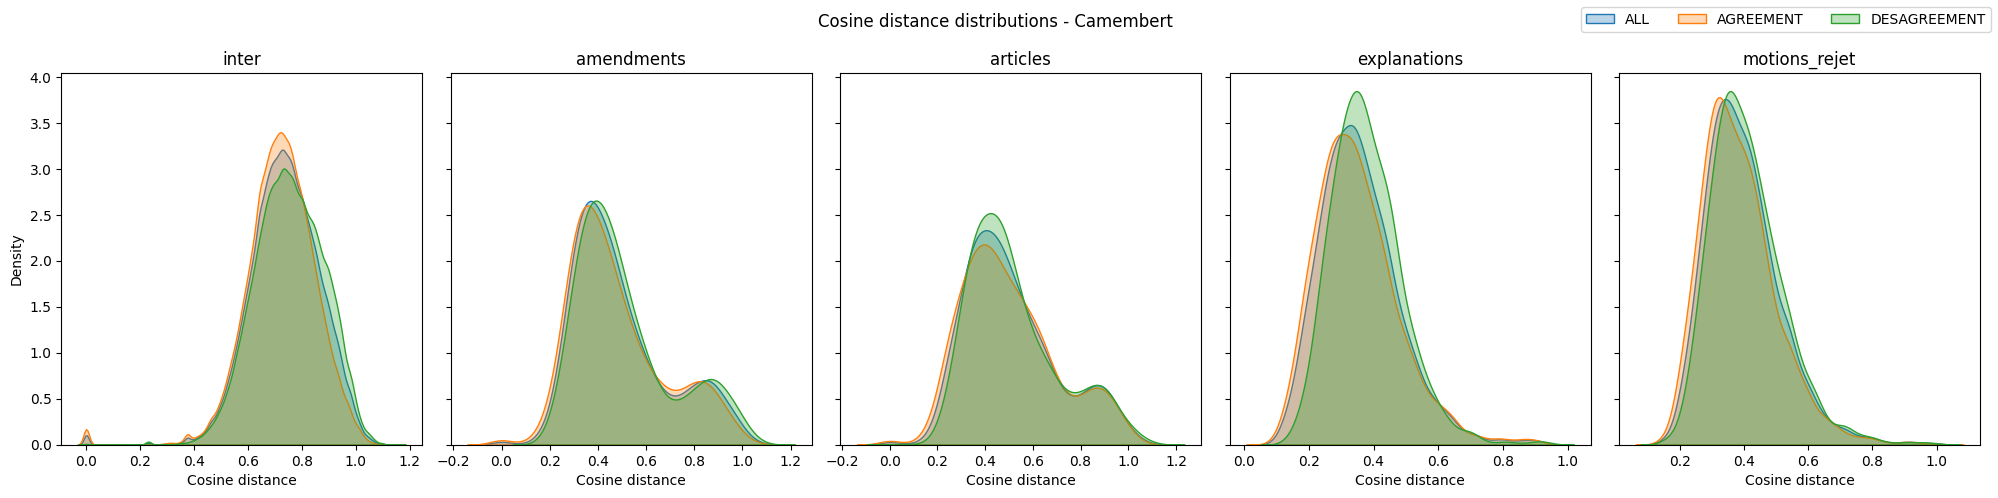

In [38]:
stats = compute_stats("embed_camembert")

groups = ["inter", "amendments", "articles", "explanations", "motions_rejet"]
labels = ["ALL", "AGREEMENT", "DESAGREEMENT"]

fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)

for ax, grp in zip(axes, groups):
    data = stats["inter"] if grp == "inter" else stats["intra"][grp]

    for lbl in labels:
        vals = data.get(lbl, np.array([]))
        if vals.size:
            sns.kdeplot(vals, ax=ax, label=lbl, fill=True, alpha=0.3)

    ax.set_title(grp)
    ax.set_xlabel("Cosine distance")
    ax.set_ylabel("Density")

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper right", ncol=3)
plt.suptitle("Cosine distance distributions - Camembert")
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


#### Qwen/Qwen3-Embedding-0.6B

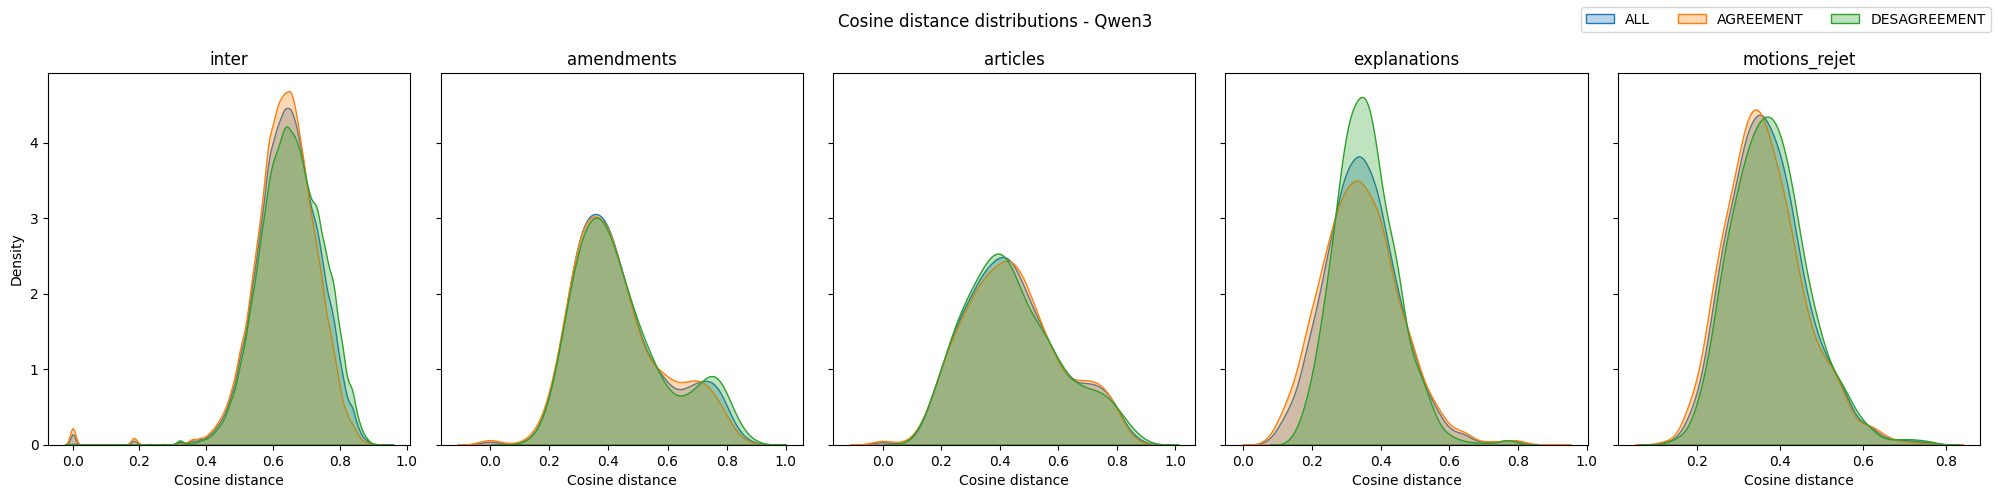

In [ ]:
stats = compute_stats("embed_qwen3")

groups = ["inter", "amendments", "articles", "explanations", "motions_rejet"]
labels = ["ALL", "AGREEMENT", "DESAGREEMENT"]

fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)

for ax, grp in zip(axes, groups):
    data = stats["inter"] if grp == "inter" else stats["intra"][grp]

    for lbl in labels:
        vals = data.get(lbl, np.array([]))
        if vals.size:
            sns.kdeplot(vals, ax=ax, label=lbl, fill=True, alpha=0.3)

    ax.set_title(grp)
    ax.set_xlabel("Cosine distance")
    ax.set_ylabel("Density")

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper right", ncol=3)
plt.suptitle("Cosine distance distributions - Qwen3")
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


#### vahidthegreat/StanceAware-SBERT

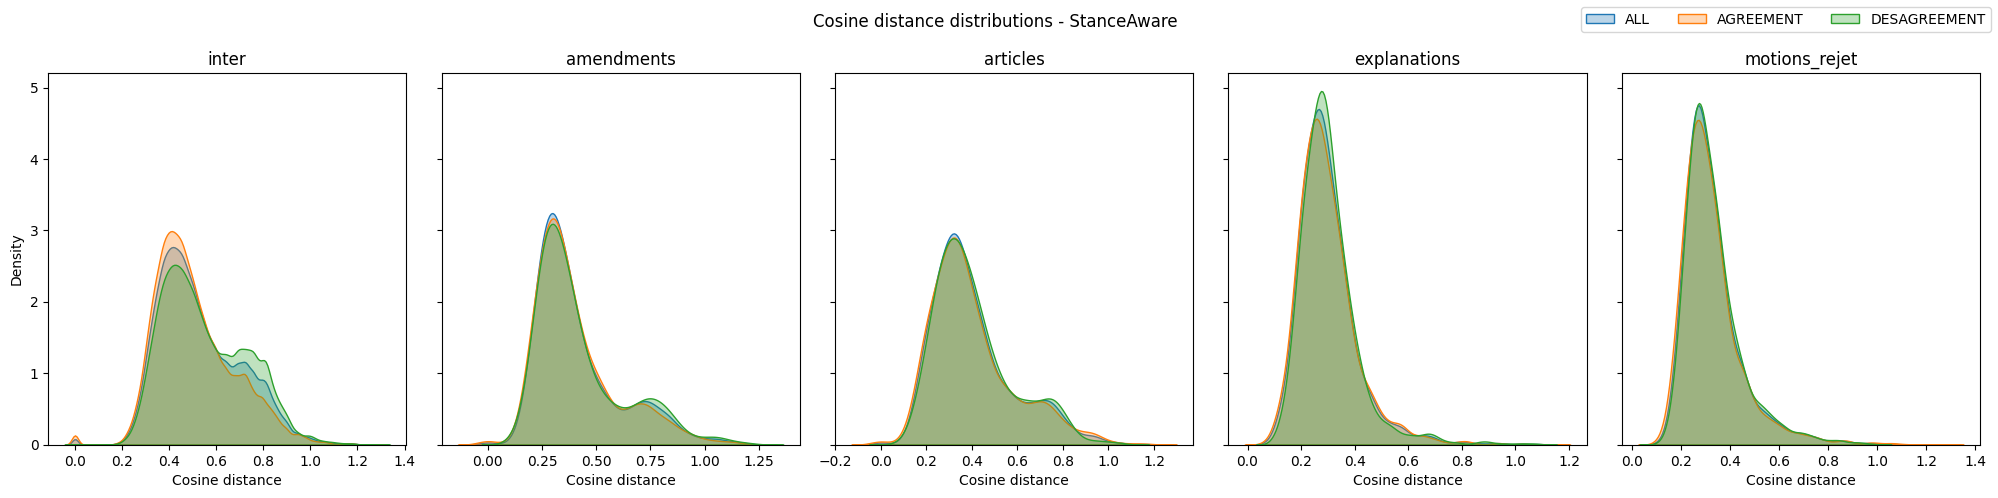

In [ ]:
stats = compute_stats("embed_stanceaware")

groups = ["inter", "amendments", "articles", "explanations", "motions_rejet"]
labels = ["ALL", "AGREEMENT", "DESAGREEMENT"]

fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)

for ax, grp in zip(axes, groups):
    data = stats["inter"] if grp == "inter" else stats["intra"][grp]

    for lbl in labels:
        vals = data.get(lbl, np.array([]))
        if vals.size:
            sns.kdeplot(vals, ax=ax, label=lbl, fill=True, alpha=0.3)

    ax.set_title(grp)
    ax.set_xlabel("Cosine distance")
    ax.set_ylabel("Density")

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper right", ncol=3)
plt.suptitle("Cosine distance distributions - StanceAware")
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


### Granularité : phrases

In [ ]:
def compute_stats_sentences(dir = "embed"):
    stats = {
        "inter": {
            "ALL": np.array([]),
            "AGREEMENT": np.array([]),
            "DESAGREEMENT": np.array([]),
        },
        "intra": {
            "amendments": {
                "ALL": np.array([]),
                "AGREEMENT": np.array([]),
                "DESAGREEMENT": np.array([]),
            },
            "articles": {
                "ALL": np.array([]),
                "AGREEMENT": np.array([]),
                "DESAGREEMENT": np.array([]),
            },
            "explanations": {
                "ALL": np.array([]),
                "AGREEMENT": np.array([]),
                "DESAGREEMENT": np.array([]),
            },
            "motions_rejet": {
                "ALL": np.array([]),
                "AGREEMENT": np.array([]),
                "DESAGREEMENT": np.array([]),
            },
        }
    }

    intervs_amds = pd.read_csv(f"./{dir}/intra_amendments.csv", converters={"embedding_sentence": literal_eval})
    intervs_other = pd.read_csv(f"./{dir}/intra_other.csv", converters={"embedding_sentence": literal_eval})

    intervs_articles = intervs_other[intervs_other["source"] == "article"]
    intervs_explanations = intervs_other[intervs_other["source"] == "explication_vote"]
    intervs_motions = intervs_other[intervs_other["source"] == "motion_rejet"]

    intra_dfs = (
        ("amendments",intervs_amds),
        ("articles", intervs_articles),
        ("explanations", intervs_explanations),
        ("motions_rejet", intervs_motions)
    )

    for grp_label, intervs in intra_dfs:
        for _, group in intervs.groupby("debate_id"):

            pour = group[group["vote"] == "POUR"][["embedding_sentence", "speech_id"]]
            contre = group[group["vote"] == "CONTRE"][["embedding_sentence", "speech_id"]]

            subsets = (("AGREEMENT", pour, pour), ("AGREEMENT", contre, contre), ("DESAGREEMENT", pour, contre))

            for label, df1, df2 in subsets:

                if len(df1) < 2 or len(df2) < 2:
                    continue

                vec1 = df1["embedding_sentence"].tolist()
                vec2 = df2["embedding_sentence"].tolist()
                ids1 = df1["speech_id"].tolist()
                ids2 = df2["speech_id"].tolist()

                cosine = cosine_distances(vec1, vec2)

                if label == "AGREEMENT":
                    rows, cols = np.triu_indices(cosine.shape[0], k=1)
                    mask = np.array([ids1[r] != ids2[c] for r, c in zip(rows, cols)])
                    cosine = cosine[rows[mask], cols[mask]]
                else:
                    rows, cols = np.indices(cosine.shape)
                    mask = np.array([ids1[r] != ids2[c] for r, c in zip(rows.flatten(), cols.flatten())])
                    cosine = cosine.flatten()[mask]

                stats["intra"][grp_label]["ALL"] = np.append(stats["intra"][grp_label]["ALL"], cosine.flatten())
                stats["intra"][grp_label][label] = np.append(stats["intra"][grp_label][label], cosine.flatten())

    intervs_inter = pd.read_csv(f"./{dir}/inter_sample.csv", converters={"embedding_sentence": literal_eval})
    pour = intervs_inter[intervs_inter["vote"] == "POUR"]["embedding_sentence"].tolist()
    contre = intervs_inter[intervs_inter["vote"] == "CONTRE"]["embedding_sentence"].tolist()

    subsets = (("AGREEMENT", pour, pour), ("AGREEMENT", contre, contre), ("DESAGREEMENT", pour, contre))
    for label, vec1, vec2 in subsets:
        cosine = cosine_distances(vec1, vec2)

        if label == "AGREEMENT":
            rows, cols = np.triu_indices(cosine.shape[0], k=1)
            cosine = cosine[rows, cols]

        stats["inter"]["ALL"] = np.append(stats["inter"]["ALL"], cosine.flatten())
        stats["inter"][label] = np.append(stats["inter"][label], cosine.flatten())

    return stats

#### Lajavaness/sentence-camembert-large

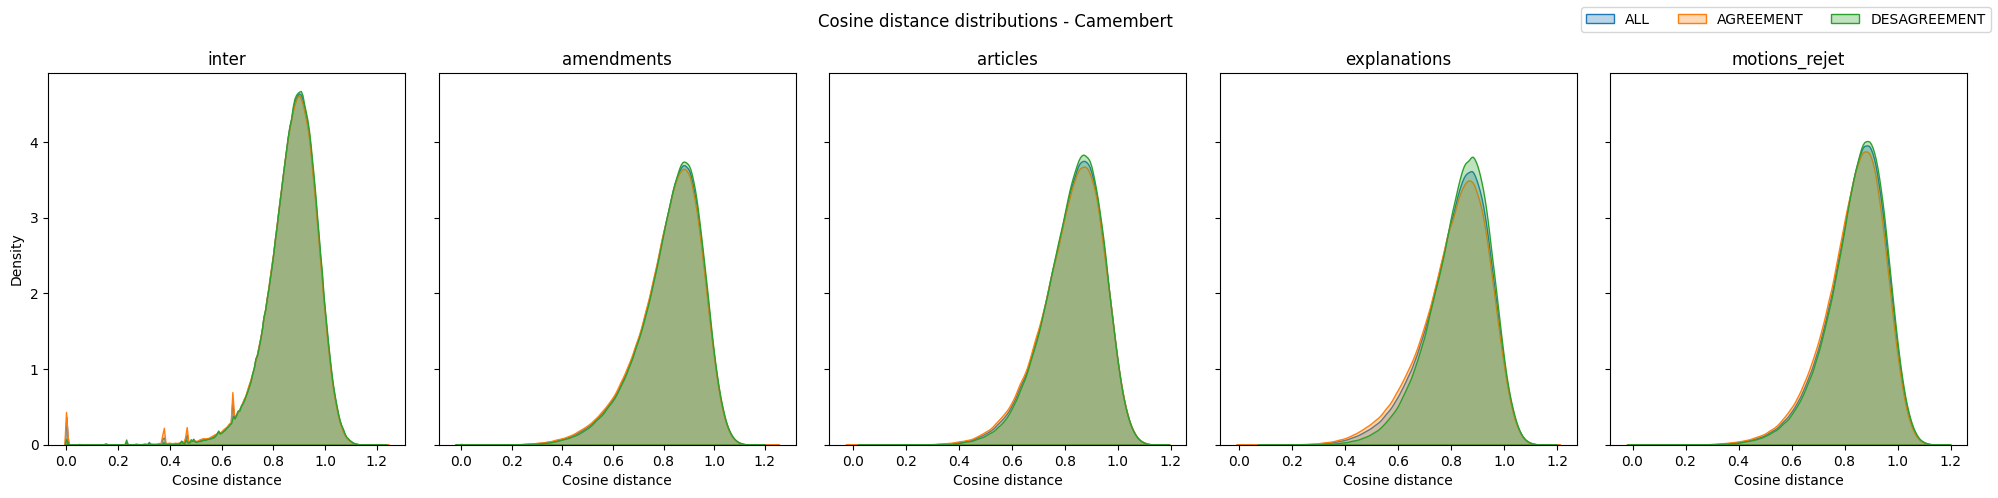

In [ ]:
stats = compute_stats_sentences("embed_sentences_camembert")

groups = ["inter", "amendments", "articles", "explanations", "motions_rejet"]
labels = ["ALL", "AGREEMENT", "DESAGREEMENT"]

fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)

for ax, grp in zip(axes, groups):
    data = stats["inter"] if grp == "inter" else stats["intra"][grp]

    for lbl in labels:
        vals = data.get(lbl, np.array([]))
        if vals.size:
            sns.kdeplot(vals, ax=ax, label=lbl, fill=True, alpha=0.3)

    ax.set_title(grp)
    ax.set_xlabel("Cosine distance")
    ax.set_ylabel("Density")

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper right", ncol=3)
plt.suptitle("Cosine distance distributions - Camembert")
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


#### Qwen/Qwen3-Embedding-0.6B

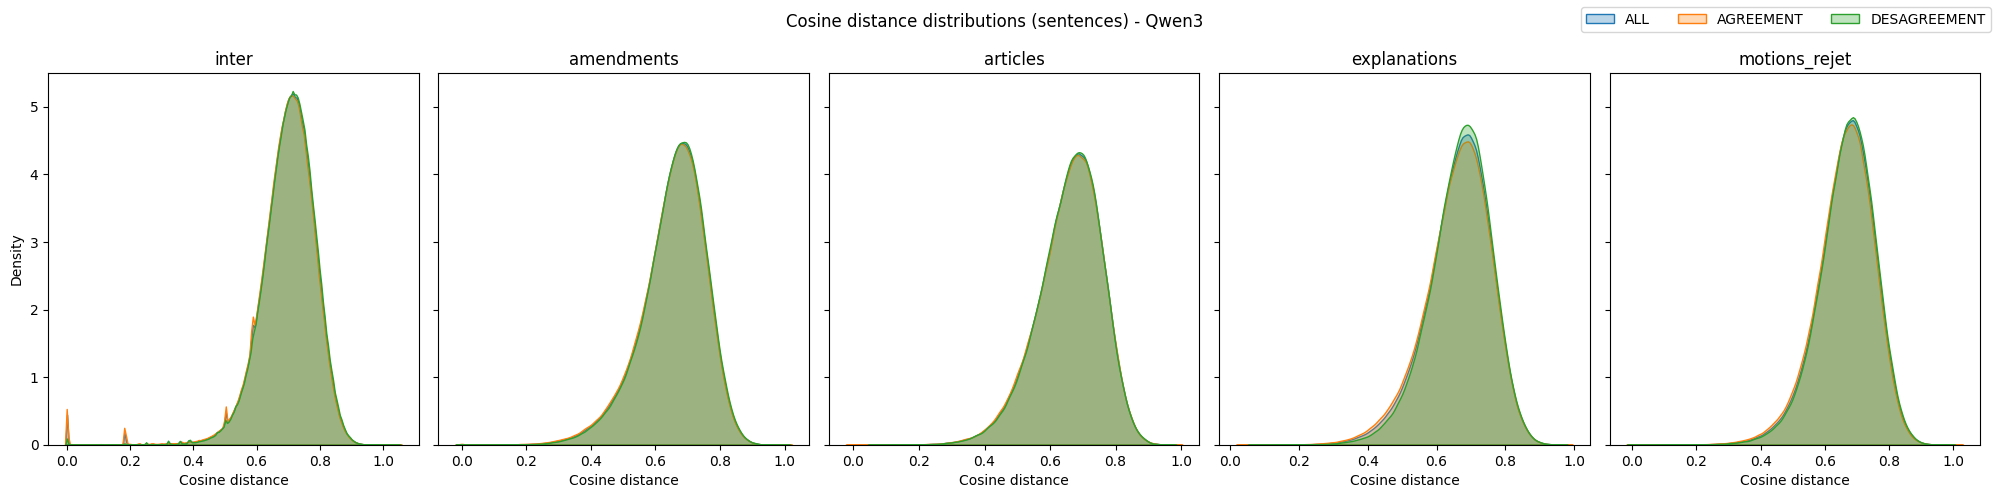

In [ ]:
stats = compute_stats_sentences("embed_sentences_qwen3")

groups = ["inter", "amendments", "articles", "explanations", "motions_rejet"]
labels = ["ALL", "AGREEMENT", "DESAGREEMENT"]

fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)

for ax, grp in zip(axes, groups):
    data = stats["inter"] if grp == "inter" else stats["intra"][grp]

    for lbl in labels:
        vals = data.get(lbl, np.array([]))
        if vals.size:
            sns.kdeplot(vals, ax=ax, label=lbl, fill=True, alpha=0.3)

    ax.set_title(grp)
    ax.set_xlabel("Cosine distance")
    ax.set_ylabel("Density")

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper right", ncol=3)
plt.suptitle("Cosine distance distributions (sentences) - Qwen3")
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


## Comparaison de distance X-Stance

X-Stance se compose de paires de question/réponse adressé à des élus suisses. La réponse est accompagnée d'un label "in favor" ou "against". Pour tester nos modèles, on regroupe les réponses par question et on construit des paires de réponses liées par la même question. On indique un label "agree" ou "disagree" selon si les deux réponses s'accordent ou non sur leur stance "in favor" ou "against" au regard de la question.

In [34]:
def compute_stats_xstance(dir="embed_camembert"):
    xstance = pd.read_csv(join(dir, "xstance_complete.csv"), converters={"embedding_comment": literal_eval})

    stats = {
        "intra": {
            "ALL": np.array([]),
            "AGREEMENT": np.array([]),
            "DESAGREEMENT": np.array([])
        },
        "inter": {
            "ALL": np.array([]),
            "AGREEMENT": np.array([]),
            "DESAGREEMENT": np.array([])
        }
    }

    for _, group in xstance.groupby("question_id"):
        favor = group[group["label"] == "FAVOR"]["embedding_comment"].tolist()
        against = group[group["label"] == "AGAINST"]["embedding_comment"].tolist()


        subsets = (("AGREEMENT", favor, favor), ("AGREEMENT", against, against), ("DESAGREEMENT", favor, against))

        for label, vec1, vec2 in subsets:

            if len(vec1) < 2 or len(vec2) < 2: 
                continue

            cosine = cosine_distances(vec1, vec2)

            if label == "AGREEMENT":
                rows, cols = np.triu_indices(cosine.shape[0], k=1)
                cosine = cosine[rows, cols]


            stats["intra"]["ALL"] = np.append(stats["intra"]["ALL"], cosine.flatten())
            stats["intra"][label] = np.append(stats["intra"][label], cosine.flatten())
    
    sample = xstance.drop_duplicates(subset="question_id")

    favor = sample[sample["label"] == "FAVOR"]["embedding_comment"].tolist()
    against = sample[sample["label"] == "AGAINST"]["embedding_comment"].tolist()

    subsets = (("AGREEMENT", favor, favor), ("AGREEMENT", against, against), ("DESAGREEMENT", favor, against))

    for label, vec1, vec2 in subsets:

        if len(vec1) < 2 or len(vec2) < 2: 
            continue

        cosine = cosine_distances(vec1, vec2)

        if label == "AGREEMENT":
            rows, cols = np.triu_indices(cosine.shape[0], k=1)
            cosine = cosine[rows, cols]
    
        stats["inter"]["ALL"] = np.append(stats["inter"]["ALL"], cosine.flatten())
        stats["inter"][label] = np.append(stats["inter"][label], cosine.flatten())

    return stats



In [35]:
x_stats = compute_stats_xstance("embed_camembert")

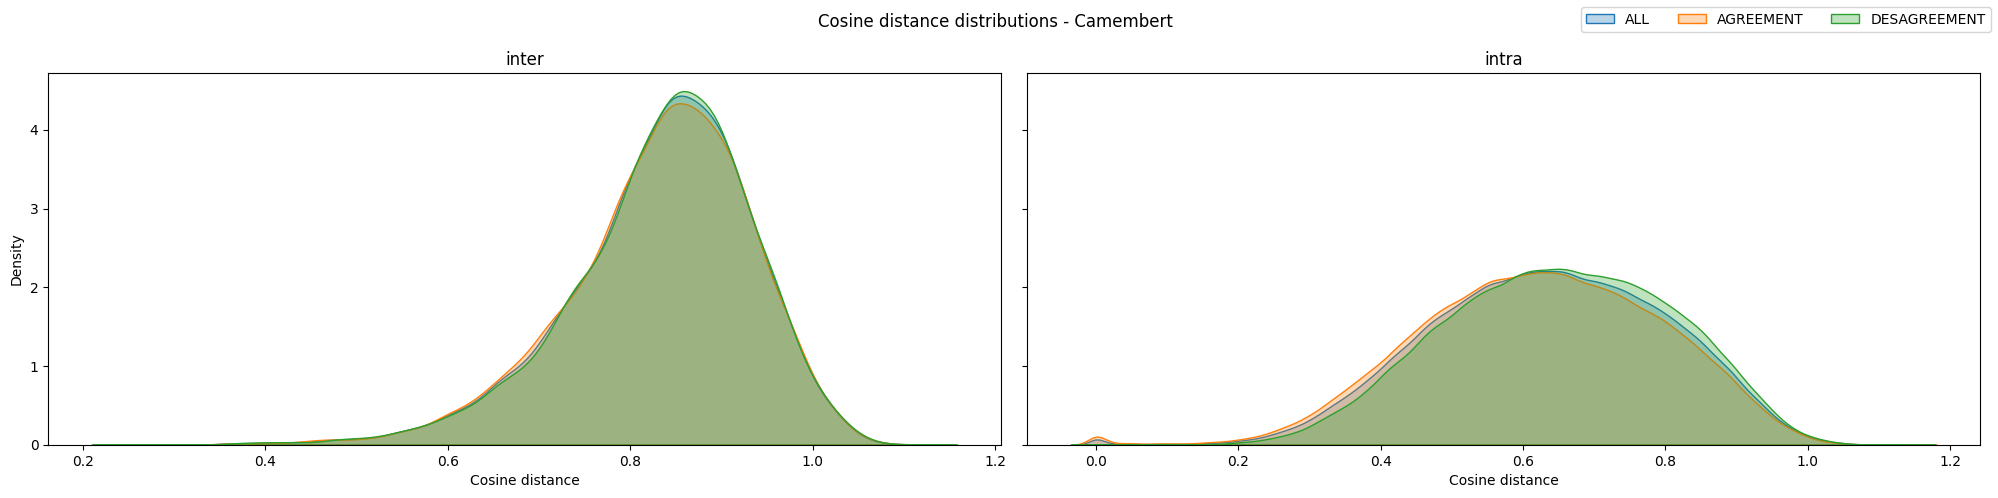

In [ ]:
groups = ["inter", "intra"]
labels = ["ALL", "AGREEMENT", "DESAGREEMENT"]

fig, axes = plt.subplots(1, 2, figsize=(20, 5), sharey=True)

for ax, grp in zip(axes, groups):
    for lbl in labels:
        vals = x_stats[grp].get(lbl, np.array([]))
        if vals.size:
            sns.kdeplot(vals, ax=ax, label=lbl, fill=True, alpha=0.3)

    ax.set_title(grp)
    ax.set_xlabel("Cosine distance")
    ax.set_ylabel("Density")

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper right", ncol=3)
plt.suptitle("Cosine distance distributions - Camembert")
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


In [ ]:
x_stats = compute_stats_xstance("embed_qwen3")

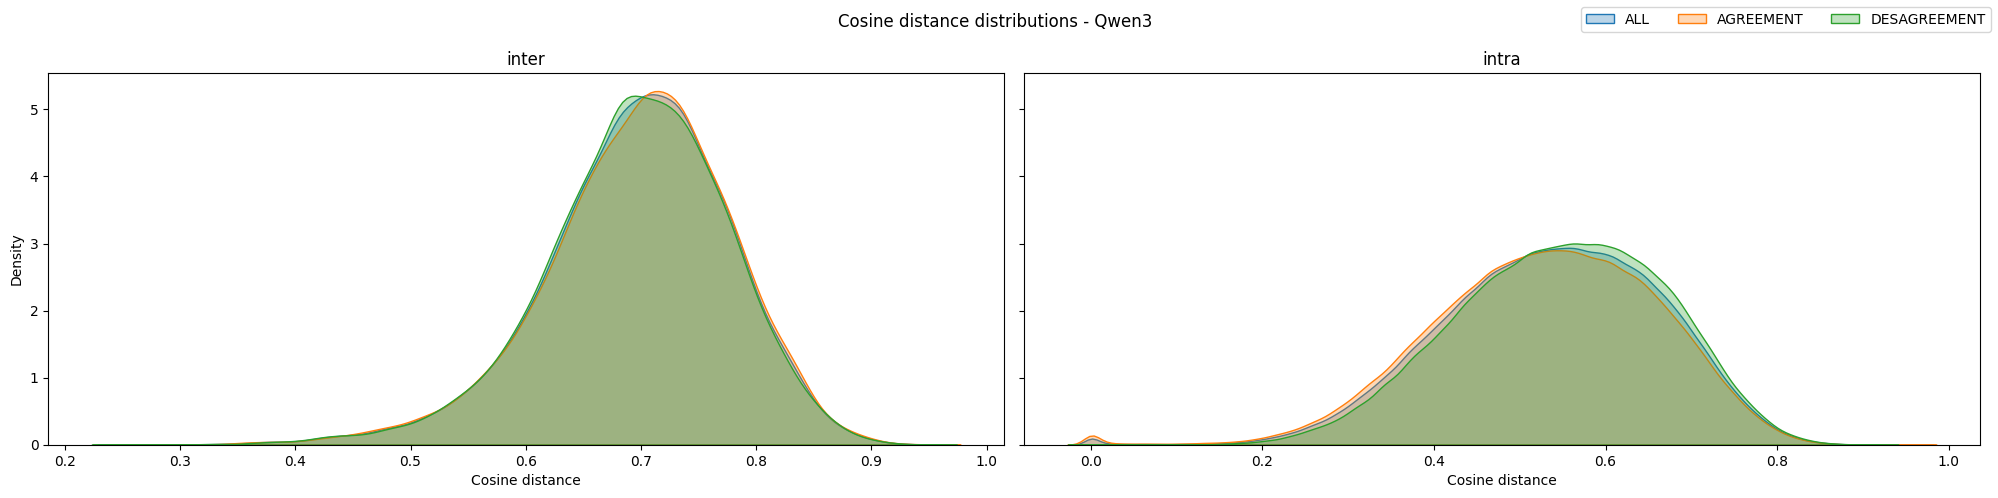

In [ ]:
groups = ["inter", "intra"]
labels = ["ALL", "AGREEMENT", "DESAGREEMENT"]

fig, axes = plt.subplots(1, 2, figsize=(20, 5), sharey=True)

for ax, grp in zip(axes, groups):
    for lbl in labels:
        vals = x_stats[grp].get(lbl, np.array([]))
        if vals.size:
            sns.kdeplot(vals, ax=ax, label=lbl, fill=True, alpha=0.3)

    ax.set_title(grp)
    ax.set_xlabel("Cosine distance")
    ax.set_ylabel("Density")

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper right", ncol=3)
plt.suptitle("Cosine distance distributions - Qwen3")
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


In [ ]:
x_stats = compute_stats_xstance("embed_stanceaware")

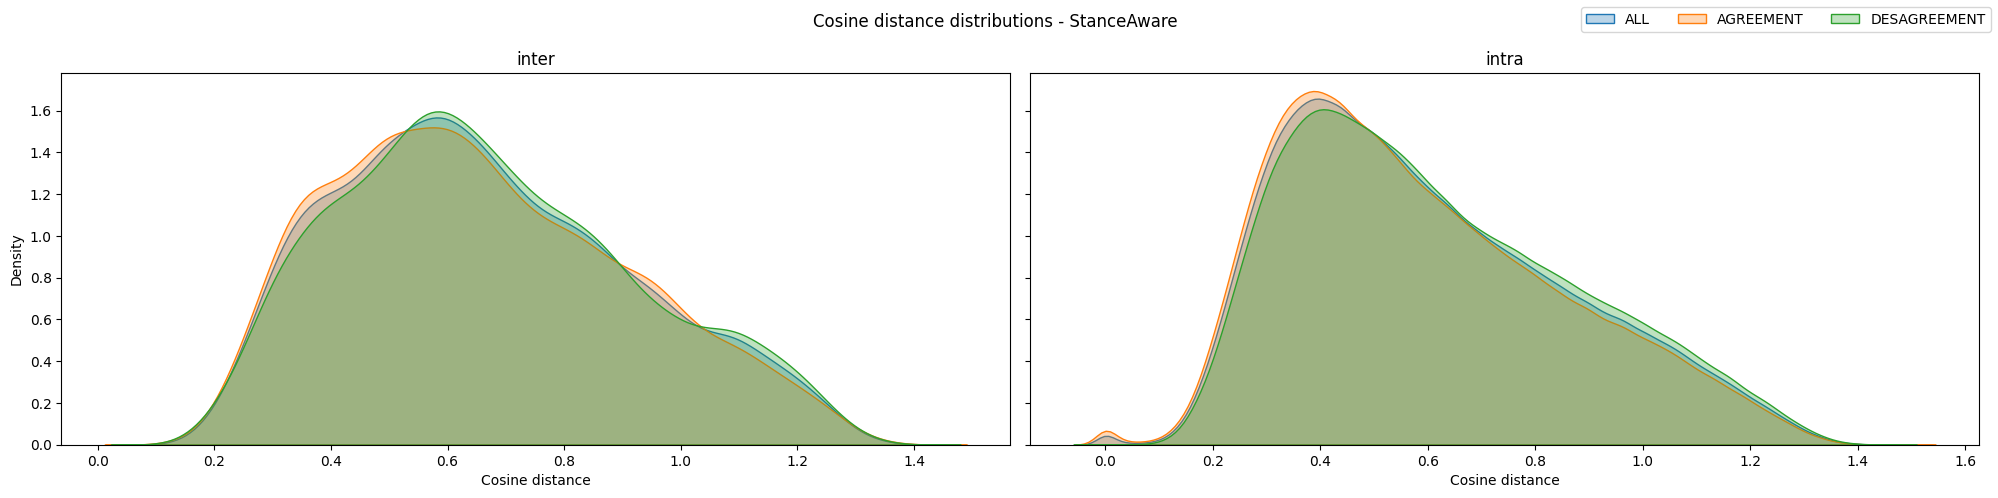

In [ ]:
groups = ["inter", "intra"]
labels = ["ALL", "AGREEMENT", "DESAGREEMENT"]

fig, axes = plt.subplots(1, 2, figsize=(20, 5), sharey=True)

for ax, grp in zip(axes, groups):
    for lbl in labels:
        vals = x_stats[grp].get(lbl, np.array([]))
        if vals.size:
            sns.kdeplot(vals, ax=ax, label=lbl, fill=True, alpha=0.3)

    ax.set_title(grp)
    ax.set_xlabel("Cosine distance")
    ax.set_ylabel("Density")

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper right", ncol=3)
plt.suptitle("Cosine distance distributions - StanceAware")
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


## Comparaison de distance StanceAware-SBERT

StanceAware-SBERT a été entraîné sur un corpus de « claims » extraits depuis la plateforme de débat Kialo. À titre de comparaison, on ré-applique le modèle sur son corpus d'entraînement pour se représenter les performances du modèle.

In [45]:
def compute_stats_kialo(dir="embed_stanceaware"):
    kialo = pd.read_csv(join(dir, "kialo.csv"), converters={"embedding_sentence_i": literal_eval, "embedding_sentence_j": literal_eval})

    stats = {
        "all": {
            "ALL": np.array([]),
            "AGREEMENT": np.array([]),
            "DESAGREEMENT": np.array([])
        }
    }

    kialo["cosine_distance"] = paired_cosine_distances(kialo["embedding_sentence_i"].tolist(), kialo["embedding_sentence_j"].tolist())

    stats["all"]["ALL"] = np.append(stats["all"]["ALL"], kialo["cosine_distance"])
    stats["all"]["AGREEMENT"] = np.append(stats["all"]["AGREEMENT"], kialo[kialo["stance"] == "Pro"]["cosine_distance"])
    stats["all"]["DESAGREEMENT"] = np.append(stats["all"]["AGREEMENT"], kialo[kialo["stance"] == "Con"]["cosine_distance"])

    return stats



In [47]:
x_stats = compute_stats_kialo("./embed_stanceaware")

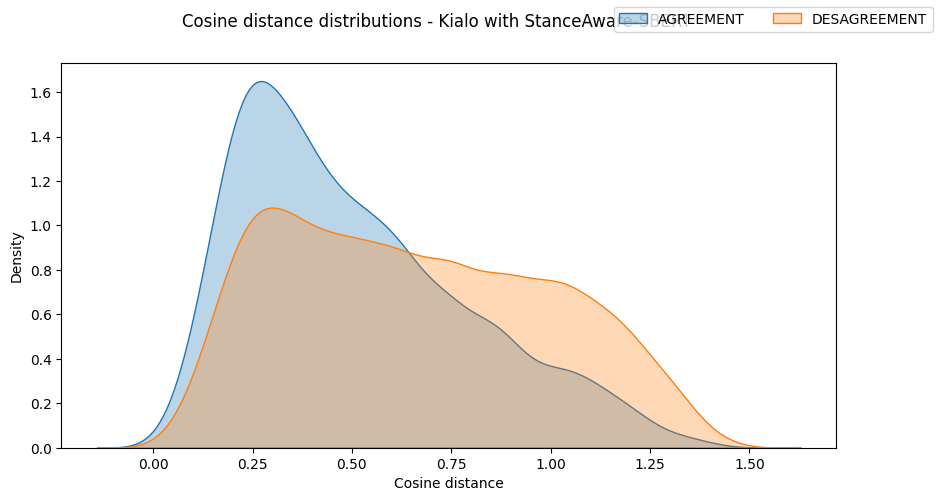

In [61]:
labels = ["AGREEMENT", "DESAGREEMENT"]

fig, axes = plt.subplots(1, 1, figsize=(10, 5), sharey=True)

for lbl in labels:
    vals = x_stats["all"].get(lbl, np.array([]))
    if vals.size:
        sns.kdeplot(vals, ax=axes, label=lbl, fill=True, alpha=0.3)

axes.set_xlabel("Cosine distance")
axes.set_ylabel("Density")

handles, legend_labels = axes.get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="upper right", ncol=3)

plt.suptitle("Cosine distance distributions - Kialo with StanceAware-SBERT")

plt.show()


### Analyse des incohérences

Observations :
- avec Qwen3 et Camembert, il y a une distribution plus forte vers 0.6-0.8 de distance sur les amendements et les articles
- avec la phrase comme granularité, il y a des pics de distributions vers jusqu'à 0.6-0.7

In [ ]:
# TODO

## Analyse des embeddings

In [ ]:
# TODO